<a href="https://colab.research.google.com/github/strzelnat/machine_learning_basics/blob/main/lesson6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.figure_factory as ff

sns.set(font_scale = 1.3)
np.set_printoptions(precision = 6, suppress = True, edgeitems = 10, linewidth = 100000, formatter = dict(float = lambda x: f'{x:.4f}'))

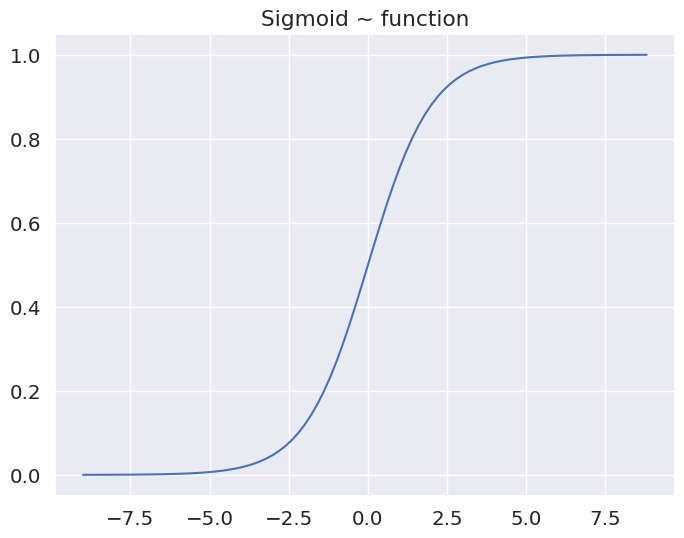

In [14]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

X = np.arange(-9, 9, 0.2)
y = sigmoid(X)

plt.figure(figsize=(8,6))
plt.plot(X,y)
plt.title('Sigmoid ~ function')
plt.show()

In [22]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [26]:
print(data.data)

[[17.9900 10.3800 122.8000 1001.0000 0.1184 0.2776 0.3001 0.1471 0.2419 0.0787 ... 25.3800 17.3300 184.6000 2019.0000 0.1622 0.6656 0.7119 0.2654 0.4601 0.1189]
 [20.5700 17.7700 132.9000 1326.0000 0.0847 0.0786 0.0869 0.0702 0.1812 0.0567 ... 24.9900 23.4100 158.8000 1956.0000 0.1238 0.1866 0.2416 0.1860 0.2750 0.0890]
 [19.6900 21.2500 130.0000 1203.0000 0.1096 0.1599 0.1974 0.1279 0.2069 0.0600 ... 23.5700 25.5300 152.5000 1709.0000 0.1444 0.4245 0.4504 0.2430 0.3613 0.0876]
 [11.4200 20.3800 77.5800 386.1000 0.1425 0.2839 0.2414 0.1052 0.2597 0.0974 ... 14.9100 26.5000 98.8700 567.7000 0.2098 0.8663 0.6869 0.2575 0.6638 0.1730]
 [20.2900 14.3400 135.1000 1297.0000 0.1003 0.1328 0.1980 0.1043 0.1809 0.0588 ... 22.5400 16.6700 152.2000 1575.0000 0.1374 0.2050 0.4000 0.1625 0.2364 0.0768]
 [12.4500 15.7000 82.5700 477.1000 0.1278 0.1700 0.1578 0.0809 0.2087 0.0761 ... 15.4700 23.7500 103.4000 741.6000 0.1791 0.5249 0.5355 0.1741 0.3985 0.1244]
 [18.2500 19.9800 119.6000 1040.0000 0.09

In [27]:
data_2 = data.copy()

data = data_2['data']
target = data_2['target']

In [29]:
data.shape

(569, 30)

In [30]:
target.shape

(569,)

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data, target)

In [38]:
print(f'train: {X_train.shape}')
print(f'train: {y_train.shape}')
print(f'test: {X_test.shape}')
print(f'test: {y_test.shape}')

train: (426, 30)
train: (426,)
test: (143, 30)
test: (143,)


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

X_train

array([[-0.0701, -0.7835, -0.1213, -0.1709, -0.6117, -0.6963, -0.9576, -0.9875, -1.4812, -0.6475, ..., -0.1822, -1.2804, -0.2546, -0.2831, -1.1591, -0.9151, -1.1018, -1.2234, -1.6845, -0.8835],
       [1.7178, 0.0877, 1.7144, 1.6540, 1.1838, 0.8061, 1.4943, 1.9715, -0.3261, -0.3541, ..., 1.1814, -0.0636, 1.1393, 1.0120, 1.5238, 0.2204, 1.1765, 1.5412, 0.2167, -0.2060],
       [-0.4976, 0.7615, -0.5330, -0.4990, -1.0583, -0.9754, -0.8779, -0.9193, -0.9779, -0.4643, ..., -0.4041, 1.0487, -0.4041, -0.4234, -0.3267, -0.4703, -0.6980, -0.7696, 0.3269, -0.1375],
       [-0.2294, 2.0672, -0.2623, -0.3015, -0.7160, -0.6671, -0.7240, -0.4054, -0.6737, -0.7434, ..., -0.3638, 1.8814, -0.4117, -0.4122, -1.1591, -0.7270, -0.7752, -0.5260, -0.6894, -1.0800],
       [-0.7294, 0.2829, -0.5573, -0.7200, 3.2702, 3.2881, 1.8342, 1.4433, 2.8352, 4.9288, ..., -0.2549, 0.1662, -0.2265, -0.5160, 3.4828, 3.6927, 1.8941, 2.1446, 6.0612, 4.7345],
       [0.0472, 0.3178, 0.0420, -0.0816, -0.5303, 0.1056, -0.4729

In [41]:
scaler.mean_

array([14.0311, 19.1623, 91.3714, 648.1045, 0.0967, 0.1051, 0.0897, 0.0486, 0.1814, 0.0630, 0.4102, 1.2088, 2.8979, 41.2619, 0.0072, 0.0259, 0.0326, 0.0119, 0.0206, 0.0038, 16.1735, 25.4658, 106.6849, 875.4488, 0.1328, 0.2579, 0.2749, 0.1146, 0.2898, 0.0846])

In [42]:
scaler.scale_

array([3.5795, 4.3042, 24.7481, 363.9113, 0.0140, 0.0544, 0.0827, 0.0392, 0.0276, 0.0070, 0.2958, 0.5121, 2.1339, 49.7717, 0.0031, 0.0179, 0.0325, 0.0063, 0.0085, 0.0024, 4.9574, 6.2211, 34.5067, 596.4079, 0.0221, 0.1648, 0.2175, 0.0666, 0.0617, 0.0187])

In [43]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

In [47]:
y_pred = log_reg.predict(X_test)
y_pred[:20]

array([0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1])

In [70]:
compare = pd.DataFrame({'model_prediction': y_pred, 'reality': y_test})
compare['error'] = abs(compare['model_prediction'] - compare['reality'])
compare['error'].sum()

np.int64(4)

In [71]:
from sklearn.metrics import confusion_matrix, accuracy_score
from mlxtend.plotting import plot_confusion_matrix

cm = confusion_matrix(y_pred,y_test)
cm

array([[55,  1],
       [ 3, 84]])

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

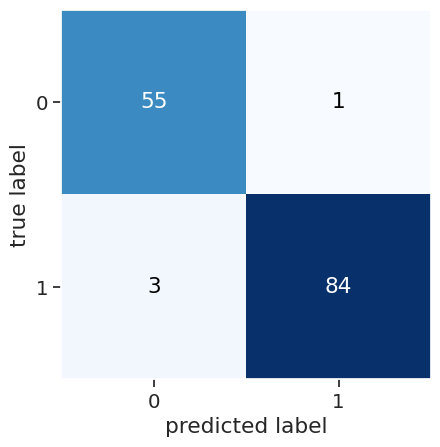

In [80]:
plot_confusion_matrix(cm)

In [76]:
accuracy_score(y_pred, y_test)

0.972027972027972

In [82]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        58
           1       0.97      0.99      0.98        85

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143

